In [1]:
# Importando as bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carregando o dataset de reviews a partir da pasta local 'data'
# O caminho agora é relativo à raiz do seu projeto.
reviews_df = pd.read_csv('data/olist_order_reviews_dataset.csv')

# Visualizando as primeiras linhas para entender a estrutura
reviews_df.head()

# Verificando informações básicas e tipos de dados como linhas, colunas e o nome de cada coluna
reviews_df.info()

# Verificando a distribuição das notas (review_score) 
# value_score (conta quantas vezes cada valor único aparece)
reviews_df['review_score'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


review_score
5    57328
4    19142
1    11424
3     8179
2     3151
Name: count, dtype: int64

In [2]:
# Criando a coluna 'sentimento' (1 para Positiva, 0 para Negativa)
df = reviews_df.copy()
df = df.dropna(subset=['review_comment_message']) # Usar apenas reviews com texto

def classificar_sentimento(nota):
    if nota >= 4:
        return 1 # Positiva
    elif nota <= 2:
        return 0 # Negativa
    else:
        return np.nan # Marcar nota 3 como NaN para remover

df['sentimento'] = df['review_score'].apply(classificar_sentimento)
df_classificado = df.dropna(subset=['sentimento'])
df_classificado['sentimento'] = df_classificado['sentimento'].astype(int)

print("Distribuição de Sentimento:")
df_classificado['sentimento'].value_counts()

Distribuição de Sentimento:


C:\Users\otavi\AppData\Local\Temp\ipykernel_29984\3826336658.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_classificado['sentimento'] = df_classificado['sentimento'].astype(int)


sentimento
1    26530
0    10890
Name: count, dtype: int64

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
import re

# Baixar a lista de stopwords em português (só precisa rodar uma vez)
try:
    stopwords_pt = stopwords.words('portuguese')
except:
    nltk.download('stopwords')
    stopwords_pt = stopwords.words('portuguese')

def limpar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'[^\w\s]', '', texto)
    texto = re.sub(r'\d+', '', texto)
    palavras = [palavra for palavra in texto.split() if palavra not in stopwords_pt]
    return ' '.join(palavras)

df_classificado['review_limpa'] = df_classificado['review_comment_message'].apply(limpar_texto)

X = df_classificado['review_limpa']
y = df_classificado['sentimento']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

C:\Users\otavi\AppData\Local\Temp\ipykernel_29984\4018853806.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_classificado['review_limpa'] = df_classificado['review_comment_message'].apply(limpar_texto)


Acurácia: 0.9168893639764831

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.86      0.85      0.86      2178
           1       0.94      0.94      0.94      5306

    accuracy                           0.92      7484
   macro avg       0.90      0.90      0.90      7484
weighted avg       0.92      0.92      0.92      7484



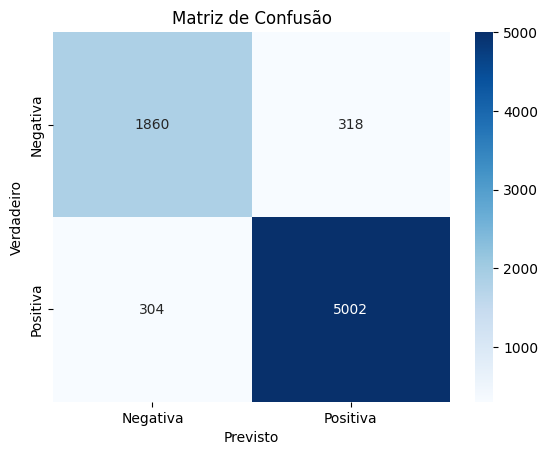

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negativa', 'Positiva'], yticklabels=['Negativa', 'Positiva'])
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão')
plt.show()

C:\Users\otavi\AppData\Local\Temp\ipykernel_29984\4294301362.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='peso', y='palavra', data=positivas_importantes, palette='Greens_r')


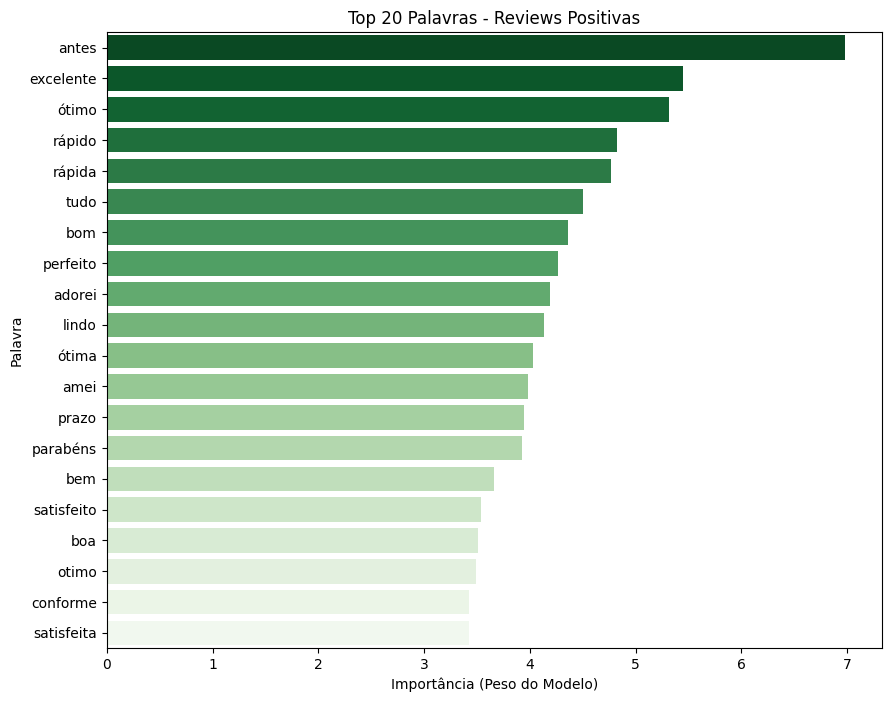

C:\Users\otavi\AppData\Local\Temp\ipykernel_29984\4294301362.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='peso', y='palavra', data=negativas_importantes.sort_values(by='peso', ascending=False), palette='Reds_r')


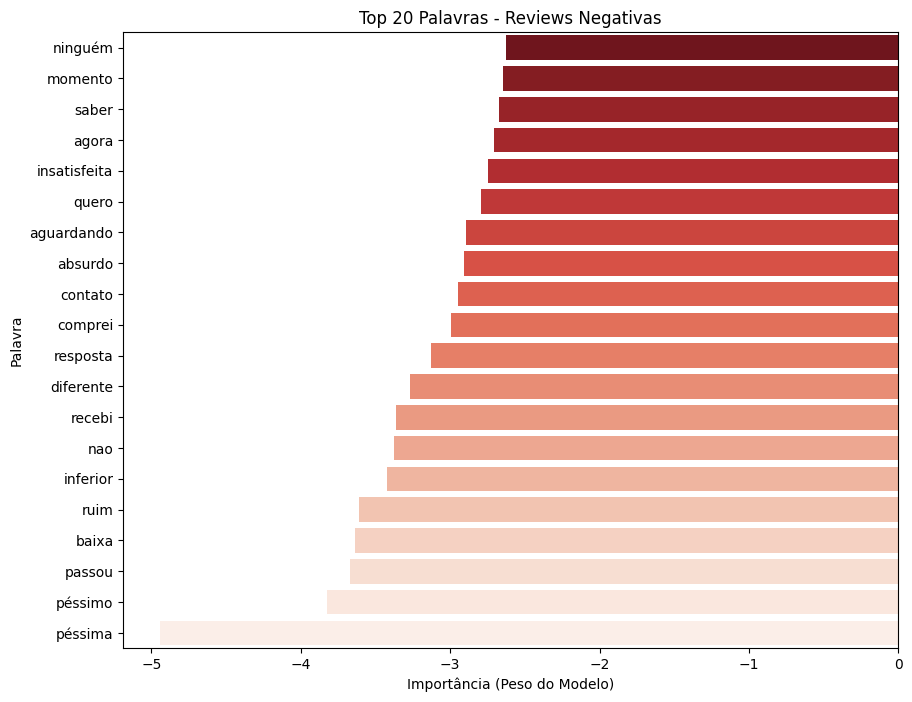

In [5]:
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
coeficientes = model.coef_[0]

df_coef = pd.DataFrame({'palavra': feature_names, 'peso': coeficientes})

positivas_importantes = df_coef.sort_values(by='peso', ascending=False).head(20)
negativas_importantes = df_coef.sort_values(by='peso', ascending=True).head(20)

# Visualizando as palavras positivas
plt.figure(figsize=(10, 8))
sns.barplot(x='peso', y='palavra', data=positivas_importantes, palette='Greens_r')
plt.title('Top 20 Palavras - Reviews Positivas')
plt.xlabel('Importância (Peso do Modelo)')
plt.ylabel('Palavra')
plt.show()

# Visualizando as palavras negativas
plt.figure(figsize=(10, 8))
sns.barplot(x='peso', y='palavra', data=negativas_importantes.sort_values(by='peso', ascending=False), palette='Reds_r')
plt.title('Top 20 Palavras - Reviews Negativas')
plt.xlabel('Importância (Peso do Modelo)')
plt.ylabel('Palavra')
plt.show()